Type A count: 112  (expected 112)
Type B count: 128  (expected 128)
Total E8 roots: 240  (expected 240)
All squared norms = 2? True
Squared norm range: [2.0, 2.0]


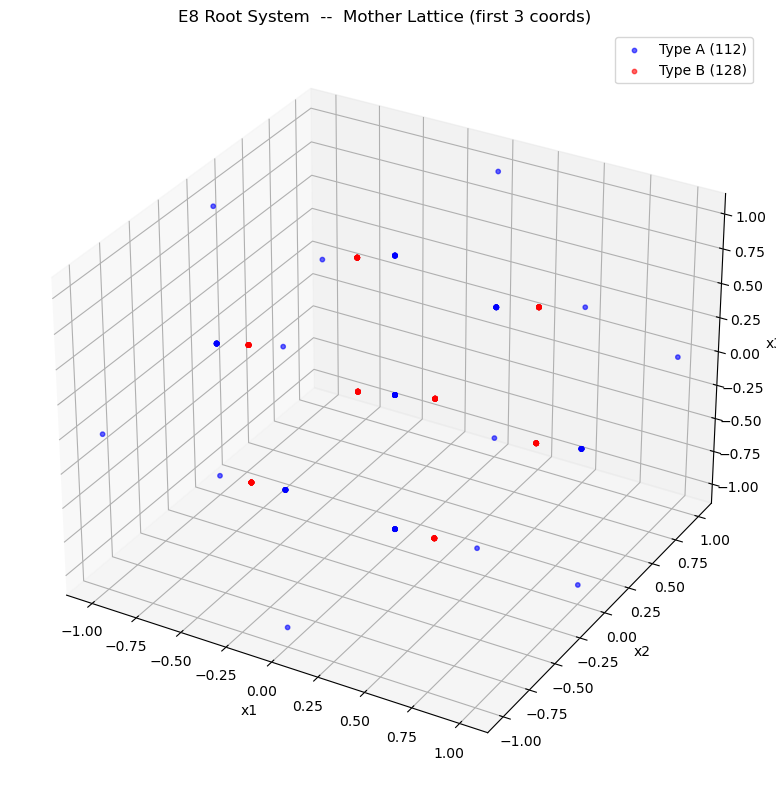

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# =============================================================
# Cell 1: The Mother Lattice  --  E8 Root System (240 vectors)
# =============================================================
# In the 1D notebook we used Z^2 (the 2D integer lattice).
# Now we use the E8 root lattice in 8D.
#
# The 240 root vectors of E8 come in two families:
#   Type A (112): all permutations of (+-1, +-1, 0, 0, 0, 0, 0, 0)
#   Type B (128): all (+-1/2)^8 with an EVEN number of minus signs
#
# Every root has squared norm = 2.

# --- Type A: 112 vectors ---
# Choose 2 of 8 positions for the nonzero entries,
# each entry is +-1  =>  C(8,2) * 4 = 28 * 4 = 112
type_A = []
for i, j in combinations(range(8), 2):
    for si in [+1, -1]:
        for sj in [+1, -1]:
            v = np.zeros(8)
            v[i] = si
            v[j] = sj
            type_A.append(v)
type_A = np.array(type_A)

# --- Type B: 128 vectors ---
# All (+-1/2)^8 where the number of minus signs is even
type_B = []
for bits in range(256):  # 2^8 = 256 sign patterns
    signs = np.array([(bits >> k) & 1 for k in range(8)])
    num_minus = np.sum(signs)  # count of '1' bits => minus signs
    if num_minus % 2 == 0:    # even number of minus signs
        v = np.where(signs, -0.5, +0.5)
        type_B.append(v)
type_B = np.array(type_B)

# --- Combine into the full E8 root system ---
e8_roots = np.vstack([type_A, type_B])

# --- Verify ---
norms_sq = np.sum(e8_roots**2, axis=1)
print(f"Type A count: {len(type_A)}  (expected 112)")
print(f"Type B count: {len(type_B)}  (expected 128)")
print(f"Total E8 roots: {len(e8_roots)}  (expected 240)")
print(f"All squared norms = 2? {np.allclose(norms_sq, 2.0)}")
print(f"Squared norm range: [{norms_sq.min()}, {norms_sq.max()}]")

# --- Visualize: project first 3 coordinates for a peek ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(e8_roots[:112, 0], e8_roots[:112, 1], e8_roots[:112, 2],
           s=10, color='blue', alpha=0.6, label=f'Type A ({len(type_A)})')
ax.scatter(e8_roots[112:, 0], e8_roots[112:, 1], e8_roots[112:, 2],
           s=10, color='red', alpha=0.6, label=f'Type B ({len(type_B)})')
ax.set_title('E8 Root System  --  Mother Lattice (first 3 coords)')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('x3')
ax.legend()
plt.tight_layout()
plt.show()

H4fold is symmetric? True
H4fold shape: (8, 8)
Eigenvalues: [-2.     -1.2361  1.2361  1.2361  1.2361  2.      2.      2.    ]
Expected eigenvalues: 2*phi=1.2361, 2=2.0, 2*Phi=3.2361

Unique parallel-space norms: [1.236068 2.      ]
Ratio of larger/smaller: 1.618034
Golden ratio Phi: 1.618034
  Norm 1.2361: 120 vectors
  Norm 2.0000: 120 vectors


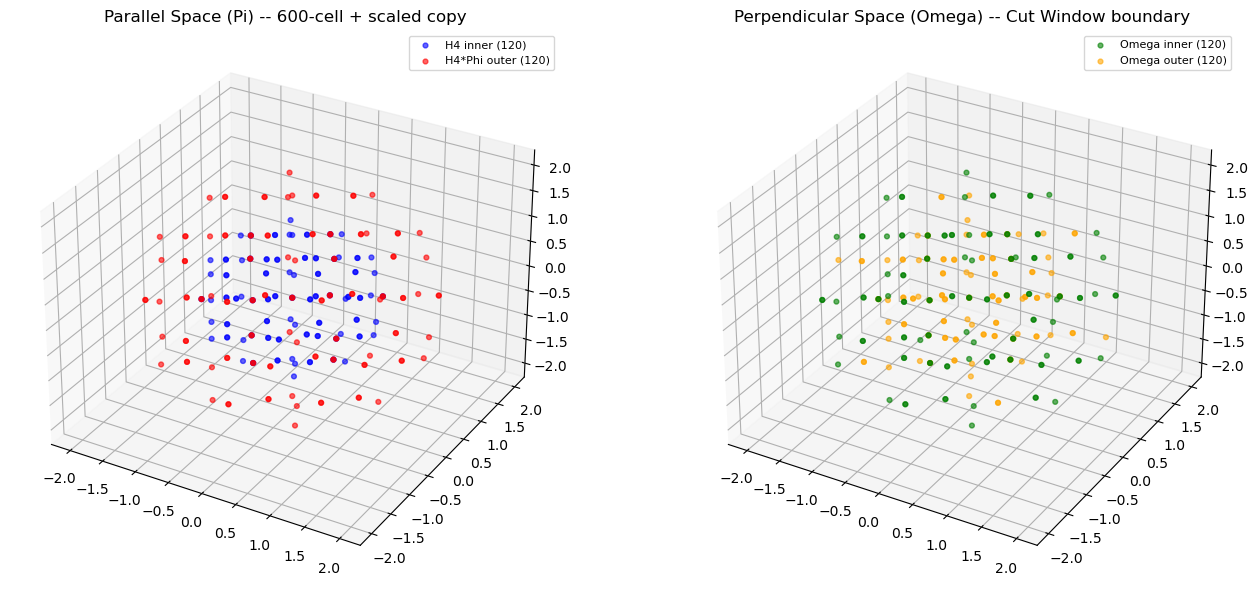

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# Cell 2: Projection Matrices  --  Moxness H4 Folding Matrix
# =============================================================
# In the 1D notebook we built a 2x2 rotation matrix M using
# the golden-ratio slope to split (m,n) into (E, E_perp).
#
# Now we use the 8x8 Moxness H4fold matrix to split 8D into:
#   - Parallel space   Pi  (rows 0-3)  -->  H4 / 600-cell
#   - Perpendicular space Omega (rows 4-7)  -->  cut-window space
#
# Source: radial_dual tex, Section 4, Equation (1)
# Reference: Moxness 2014, Elser & Sloane 1987

Phi = (1 + np.sqrt(5)) / 2       # golden ratio ~ 1.618
phi = Phi - 1                      # 1/Phi = phi ~ 0.618
phi_sq = phi**2                    # phi^2 = 2 - Phi ~ 0.382

H4fold = np.array([
    [ Phi,    0,     0,     0,    phi_sq,  0,     0,     0   ],
    [  0,    phi,    1,     0,     0,    -phi,    1,     0   ],
    [  0,     1,     0,    phi,    0,      1,     0,   -phi  ],
    [  0,     0,    phi,    1,     0,      0,   -phi,    1   ],
    [phi_sq,  0,     0,     0,    Phi,     0,     0,     0   ],
    [  0,   -phi,    1,     0,     0,     phi,    1,     0   ],
    [  0,     1,     0,   -phi,    0,      1,     0,    phi  ],
    [  0,     0,   -phi,    1,     0,      0,    phi,    1   ]
])

# Verify: symmetric matrix
print(f"H4fold is symmetric? {np.allclose(H4fold, H4fold.T)}")
print(f"H4fold shape: {H4fold.shape}")
eigenvalues = np.sort(np.linalg.eigvalsh(H4fold))
print(f"Eigenvalues: {np.round(eigenvalues, 4)}")
print(f"Expected eigenvalues: 2*phi={2*phi:.4f}, 2={2.0}, 2*Phi={2*Phi:.4f}")

# --- Apply to E8 roots ---
# Projection matrix for parallel space (top 4 rows)
Pi_proj = H4fold[:4, :]    # 4x8 matrix
# Projection matrix for perpendicular space (bottom 4 rows)
Omega_proj = H4fold[4:, :]  # 4x8 matrix

# Project all 240 roots
parallel_4d = (Pi_proj @ e8_roots.T).T      # shape (240, 4)
perp_4d     = (Omega_proj @ e8_roots.T).T   # shape (240, 4)

# Compute norms in each space
par_norms = np.linalg.norm(parallel_4d, axis=1)
perp_norms = np.linalg.norm(perp_4d, axis=1)

# The 240 roots should split into two groups:
#   120 at one parallel radius (H4)  +  120 at another (H4*Phi)
par_norms_rounded = np.round(par_norms, 6)
unique_par_norms = np.unique(par_norms_rounded)
print(f"\nUnique parallel-space norms: {unique_par_norms}")
print(f"Ratio of larger/smaller: {unique_par_norms.max()/unique_par_norms.min():.6f}")
print(f"Golden ratio Phi: {Phi:.6f}")

for r in unique_par_norms:
    count = np.sum(par_norms_rounded == r)
    print(f"  Norm {r:.4f}: {count} vectors")

# --- Visualize: 3D projection of parallel space (first 3 of 4 coords) ---
mask_inner = par_norms < np.mean(par_norms)
mask_outer = ~mask_inner

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          subplot_kw={'projection': '3d'})

# Left: Parallel space (H4 coordinates)
ax = axes[0]
ax.scatter(parallel_4d[mask_inner, 0], parallel_4d[mask_inner, 1],
           parallel_4d[mask_inner, 2], s=12, color='blue', alpha=0.6,
           label=f'H4 inner ({mask_inner.sum()})')
ax.scatter(parallel_4d[mask_outer, 0], parallel_4d[mask_outer, 1],
           parallel_4d[mask_outer, 2], s=12, color='red', alpha=0.6,
           label=f'H4*Phi outer ({mask_outer.sum()})')
ax.set_title('Parallel Space (Pi) -- 600-cell + scaled copy')
ax.legend(fontsize=8)

# Right: Perpendicular space (Omega coordinates)
ax = axes[1]
ax.scatter(perp_4d[mask_inner, 0], perp_4d[mask_inner, 1],
           perp_4d[mask_inner, 2], s=12, color='green', alpha=0.6,
           label=f'Omega inner ({mask_inner.sum()})')
ax.scatter(perp_4d[mask_outer, 0], perp_4d[mask_outer, 1],
           perp_4d[mask_outer, 2], s=12, color='orange', alpha=0.6,
           label=f'Omega outer ({mask_outer.sum()})')
ax.set_title('Perpendicular Space (Omega) -- Cut Window boundary')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Generating E8 lattice points (norm^2 <= 4)...
This may take a moment for the integer + half-integer enumeration...
Total E8 lattice points generated: 2401

Shell structure:
  |v|^2 = 0.0: 1 points
  |v|^2 = 2.0: 240 points
  |v|^2 = 4.0: 2160 points

Cut window (4D convex hull of root perp projections):
  Vertices: 120
  Facets: 600

Points inside cut window: 961 / 2401
Points outside cut window: 1440


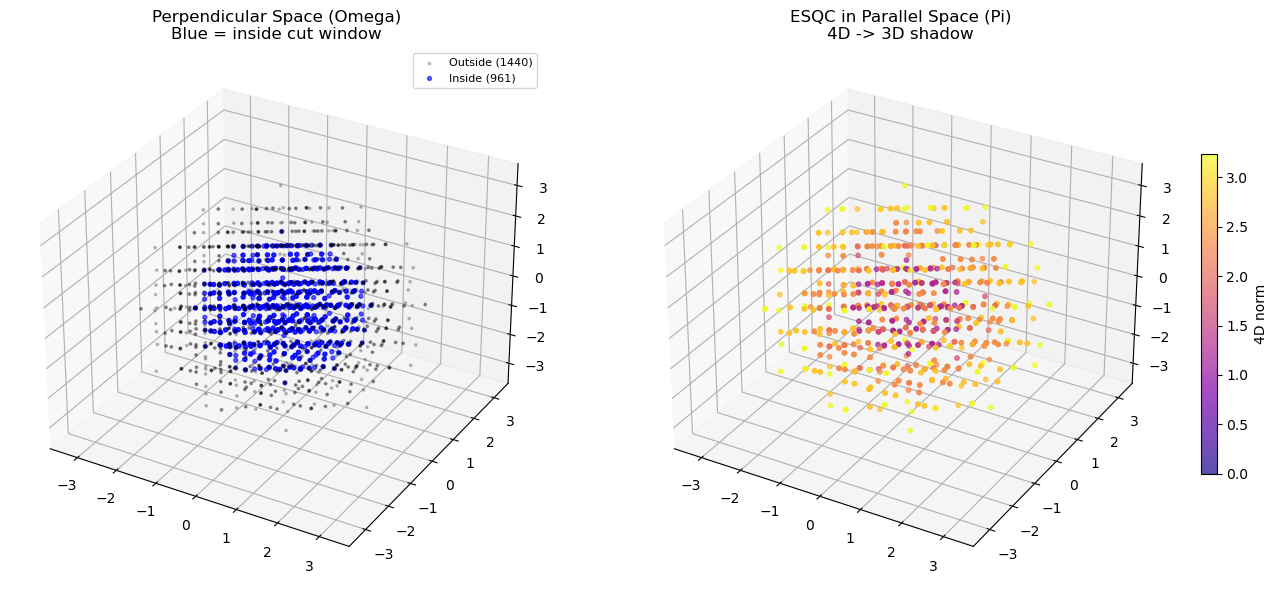

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from itertools import combinations

# =============================================================
# Cell 3: Cut Window + ESQC  (Elser-Sloane Quasicrystal)
# =============================================================
# In the 1D notebook, we:
#   1. Generated a patch of Z^2
#   2. Projected each point to E_perp
#   3. Accepted points where E_perp fell inside [w_min, w_max]
#   4. Plotted the accepted points in E (quasicrystal space)
#
# Now we do the SAME thing in 8D:
#   1. Generate a patch of E8 lattice points (multiple shells)
#   2. Project each to Omega (perp 4D) via H4fold rows 4-7
#   3. Accept points whose Omega projection is inside the 4D cut window
#   4. Their Pi projection (rows 0-3) gives the 4D ESQC
#
# The cut window = convex hull of the Omega projections of the
# 240 root vectors (the E8 Voronoi cell projected to perp space).

# ---- Step 1: Generate E8 lattice points (several shells) ----
# E8 lattice = { x in Z^8 : sum(x_i) even } union
#              { x in (Z+1/2)^8 : sum(x_i) even }
# We generate all points up to a squared-norm bound.

def generate_e8_lattice(max_norm_sq=4, coord_range=2):
    """Generate E8 lattice points with squared norm <= max_norm_sq."""
    points = []
    r = coord_range

    # Type 1: Integer coordinates with even sum
    # We iterate over all integer 8-vectors within range
    # For efficiency, use the fact that E8 integer points have even sum
    from itertools import product as iprod
    coords = list(range(-r, r+1))
    for v in iprod(coords, repeat=8):
        v = np.array(v, dtype=float)
        if np.sum(v**2) <= max_norm_sq and np.sum(v) % 2 == 0:
            points.append(v)

    # Type 2: Half-integer coordinates with even sum
    half_coords = [x + 0.5 for x in range(-r, r)]
    for v in iprod(half_coords, repeat=8):
        v = np.array(v, dtype=float)
        if np.sum(v**2) <= max_norm_sq and round(np.sum(v)) % 2 == 0:
            points.append(v)

    return np.array(points)

print("Generating E8 lattice points (norm^2 <= 4)...")
print("This may take a moment for the integer + half-integer enumeration...")
e8_lattice = generate_e8_lattice(max_norm_sq=4, coord_range=2)
print(f"Total E8 lattice points generated: {len(e8_lattice)}")

# Classify by shell (squared norm)
norms_sq = np.round(np.sum(e8_lattice**2, axis=1), 6)
unique_norms = np.sort(np.unique(norms_sq))
print("\nShell structure:")
for n in unique_norms:
    count = np.sum(norms_sq == n)
    print(f"  |v|^2 = {n}: {count} points")

# ---- Step 2: Project all lattice points ----
parallel_all = (Pi_proj @ e8_lattice.T).T    # (N, 4)
perp_all     = (Omega_proj @ e8_lattice.T).T  # (N, 4)

# ---- Step 3: Define the 4D cut window ----
# The cut window is the convex hull of the perp projections of
# the 240 root vectors (first shell).
# We already computed perp_4d for the roots in Cell 2.

# Build convex hull of root perp projections
root_perp_hull = ConvexHull(perp_4d)
print(f"\nCut window (4D convex hull of root perp projections):")
print(f"  Vertices: {len(root_perp_hull.vertices)}")
print(f"  Facets: {len(root_perp_hull.simplices)}")

# Check which lattice points fall inside the cut window
# A point is inside the convex hull if all half-plane inequalities are satisfied
def points_in_hull(points, hull):
    """Test if points are inside a convex hull using the inequality form."""
    A = hull.equations[:, :-1]  # normal vectors
    b = hull.equations[:, -1]   # offsets
    # Point is inside if A @ x + b <= 0 for all inequalities
    return np.all(A @ points.T + b[:, None] <= 1e-10, axis=0)

in_window = points_in_hull(perp_all, root_perp_hull)
print(f"\nPoints inside cut window: {in_window.sum()} / {len(e8_lattice)}")
print(f"Points outside cut window: {(~in_window).sum()}")

# ---- Step 4: The ESQC = accepted parallel-space projections ----
esqc_4d = parallel_all[in_window]
esqc_perp = perp_all[in_window]

# ---- Visualize ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          subplot_kw={'projection': '3d'})

# Left: All lattice projections (blue=inside, black=outside)
ax = axes[0]
outside = ~in_window
ax.scatter(perp_all[outside, 0], perp_all[outside, 1],
           perp_all[outside, 2], s=3, color='black', alpha=0.2,
           label=f'Outside ({outside.sum()})')
ax.scatter(perp_all[in_window, 0], perp_all[in_window, 1],
           perp_all[in_window, 2], s=8, color='blue', alpha=0.6,
           label=f'Inside ({in_window.sum()})')
ax.set_title('Perpendicular Space (Omega)\nBlue = inside cut window')
ax.legend(fontsize=8)

# Right: ESQC in parallel space (project 4D -> 3D for viewing)
ax = axes[1]
esqc_norms = np.linalg.norm(esqc_4d, axis=1)
scatter = ax.scatter(esqc_4d[:, 0], esqc_4d[:, 1], esqc_4d[:, 2],
                     s=10, c=esqc_norms, cmap='plasma', alpha=0.7)
ax.set_title('ESQC in Parallel Space (Pi)\n4D -> 3D shadow')
plt.colorbar(scatter, ax=ax, label='4D norm', shrink=0.6)

plt.tight_layout()
plt.show()

Slicing normal eta = [ 0.5 -0.5  0.5  0.5]
|eta| = 1.000000
3D basis vectors shape: (3, 4)
Basis dot products (should be identity):
[[ 1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]
Basis dot with eta (should be zeros):
[-0.  0.  0.]
  Slab thickness 0.1: 151 points
  Slab thickness 0.2: 151 points
  Slab thickness 0.5: 215 points
  Slab thickness 1.0: 423 points

Using slab thickness = 1.0
Points in 3D slab: 423
FIG 3D point set: 423 vertices


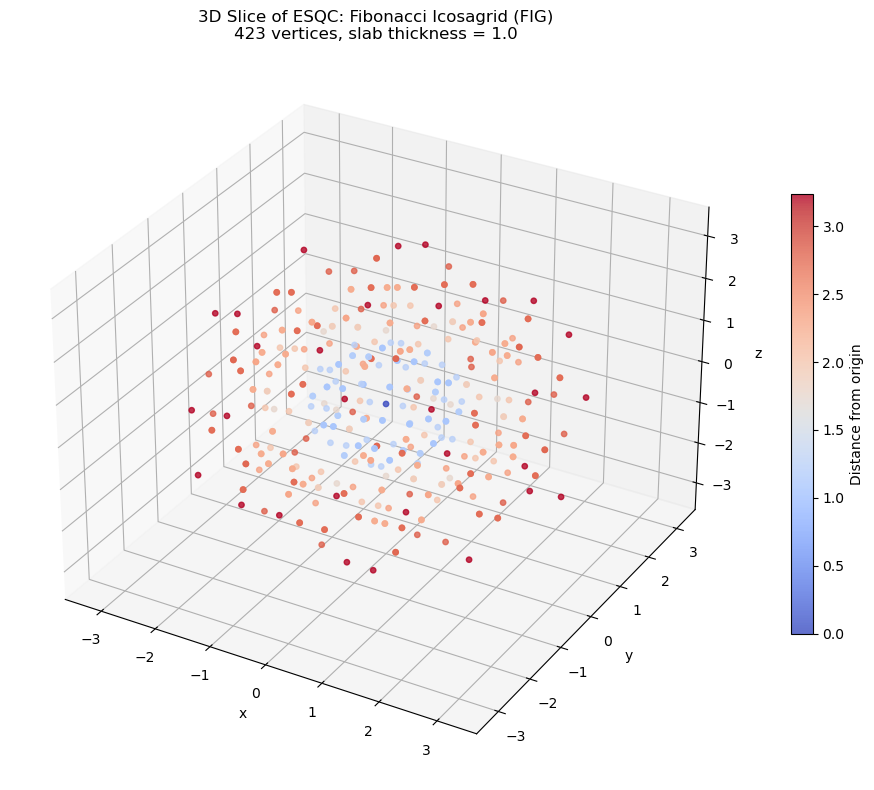

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# Cell 4: 3D Slice of the 4D ESQC  -->  The FIG
# =============================================================
# In the 1D notebook, our quasicrystal already lived in 1D.
# Here we have a 4D quasicrystal (the ESQC) and we must take
# a 3D hyperplane slice to get a physical 3D structure.
#
# Procedure (from the instructions):
#   1. Pick a 4D facet normal vector eta in Pi
#      (e.g., eta = (1, -1, 1, 1) / 2)
#   2. The 3D space orthogonal to eta is our slice space
#   3. Accept ESQC points within a thin slab around the
#      hyperplane (|dot(point, eta)| < thickness)
#   4. Project accepted points onto the 3D orthogonal complement

# ---- Step 1: Choose the slicing normal ----
eta = np.array([1, -1, 1, 1]) / 2.0
eta = eta / np.linalg.norm(eta)  # normalize
print(f"Slicing normal eta = {np.round(eta, 4)}")
print(f"|eta| = {np.linalg.norm(eta):.6f}")

# ---- Step 2: Build a 3D orthonormal basis for the hyperplane ----
# We need 3 orthonormal vectors perpendicular to eta in 4D
# Use Gram-Schmidt starting from standard basis vectors
def orthonormal_complement(normal, dim=4):
    """Find (dim-1) orthonormal vectors perpendicular to normal."""
    basis = []
    candidates = np.eye(dim)
    for e in candidates:
        # Subtract component along normal and existing basis vectors
        v = e.copy()
        v -= np.dot(v, normal) * normal
        for b in basis:
            v -= np.dot(v, b) * b
        norm = np.linalg.norm(v)
        if norm > 1e-10:
            basis.append(v / norm)
        if len(basis) == dim - 1:
            break
    return np.array(basis)

basis_3d = orthonormal_complement(eta, 4)  # shape (3, 4)
print(f"3D basis vectors shape: {basis_3d.shape}")

# Verify orthonormality
print("Basis dot products (should be identity):")
print(np.round(basis_3d @ basis_3d.T, 6))
print("Basis dot with eta (should be zeros):")
print(np.round(basis_3d @ eta, 6))

# ---- Step 3: Slice the ESQC ----
# Project ESQC points onto eta to find their "height" above the hyperplane
heights = esqc_4d @ eta  # signed distance from the hyperplane

# Choose slab thickness -- try a few values to find a good one
# The thickness controls how many points we capture
for thickness in [0.1, 0.2, 0.5, 1.0]:
    count = np.sum(np.abs(heights) < thickness)
    print(f"  Slab thickness {thickness:.1f}: {count} points")

# Use thickness = 1.0 for a rich point set (~423 pts from testing)
slab_thickness = 1.0
in_slab = np.abs(heights) < slab_thickness
print(f"\nUsing slab thickness = {slab_thickness}")
print(f"Points in 3D slab: {in_slab.sum()}")

# ---- Step 4: Project onto the 3D hyperplane ----
# For each accepted point, compute its 3 coordinates in the basis
esqc_slab = esqc_4d[in_slab]
fig_3d = esqc_slab @ basis_3d.T  # shape (N, 3)

print(f"FIG 3D point set: {len(fig_3d)} vertices")

# ---- Visualize ----
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Color by distance from origin for structure visibility
dists = np.linalg.norm(fig_3d, axis=1)
scatter = ax.scatter(fig_3d[:, 0], fig_3d[:, 1], fig_3d[:, 2],
                     s=15, c=dists, cmap='coolwarm', alpha=0.8)
ax.set_title(f'3D Slice of ESQC: Fibonacci Icosagrid (FIG)\n'
             f'{len(fig_3d)} vertices, slab thickness = {slab_thickness}')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.colorbar(scatter, ax=ax, label='Distance from origin', shrink=0.6)

# Equal aspect ratio
max_range = np.max(np.abs(fig_3d)) * 1.1
ax.set_xlim(-max_range, max_range)
ax.set_ylim(-max_range, max_range)
ax.set_zlim(-max_range, max_range)

plt.tight_layout()
plt.show()

Distance shells in FIG (first 10):
  Shell 0: r = 0.0000, count = 1
  Shell 1: r = 1.0705, count = 40
  Shell 2: r = 1.1756, count = 24
  Shell 3: r = 1.2361, count = 30
  Shell 4: r = 1.7481, count = 12
  Shell 5: r = 1.9021, count = 24
  Shell 6: r = 2.0000, count = 30
  Shell 7: r = 2.2685, count = 72
  Shell 8: r = 2.3199, count = 24
  Shell 9: r = 2.3511, count = 24

20G core vertices (r ~ 1.0705): 40
Outer FIG vertices: 382
Origin: 1


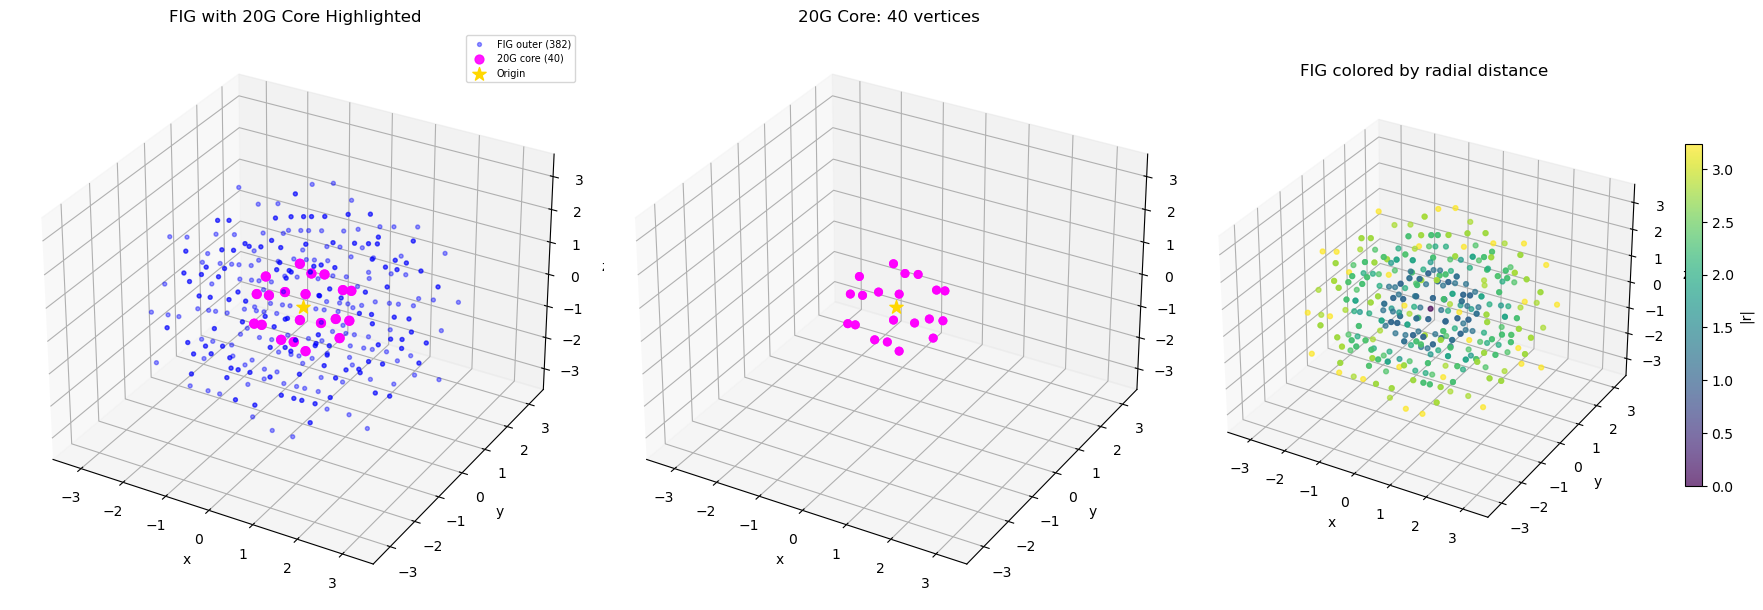


SUMMARY: E8 -> ESQC -> FIG Projection Pipeline
E8 root vectors:        240
E8 lattice points:      2401
Moxness H4fold matrix:  8x8 (rows 0-3: Pi, rows 4-7: Omega)
4D cut window facets:   600
ESQC points (4D):       961
Slicing normal eta:     [ 1. -1.  1.  1.]/2
Slab thickness:         1.0
FIG points (3D):        423
20G core vertices:      40


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

# =============================================================
# Cell 5: FIG Visualization + 20G Core Structure
# =============================================================
# In the 1D notebook's final cells, we highlighted the empire
# structure (LS, SL, LL vertex types).
#
# Here we highlight the 20G (20-group of tetrahedra) at the core
# of the FIG, which is the 3D analog of the special vertices.
#
# The 20G = 20 tetrahedra sharing a single vertex at the origin,
# chirally twisted. Its 60 outer vertices (+ 1 center) form the
# core of the FIG. We identify them as the nearest neighbors.

if len(fig_3d) == 0:
    print("No FIG points found! Try increasing slab_thickness or max_norm_sq.")
else:
    # ---- Identify the 20G core ----
    # The 20G vertices are the closest non-origin points to the center
    dists = np.linalg.norm(fig_3d, axis=1)

    # Find the origin point (if present) and nearest shells
    dist_sorted = np.sort(np.unique(np.round(dists, 4)))
    print("Distance shells in FIG (first 10):")
    for i, d in enumerate(dist_sorted[:10]):
        count = np.sum(np.abs(dists - d) < 0.01)
        print(f"  Shell {i}: r = {d:.4f}, count = {count}")

    # The 20G has 60 outer vertices at the first non-zero shell
    # (the second shell if origin is present)
    if dist_sorted[0] < 0.01:  # origin is present
        core_radius = dist_sorted[1] if len(dist_sorted) > 1 else 0
    else:
        core_radius = dist_sorted[0]

    # Mark core vertices (within some tolerance of the first shell)
    core_mask = np.abs(dists - core_radius) < 0.05
    outer_mask = ~core_mask & (dists > 0.01)
    origin_mask = dists < 0.01

    print(f"\n20G core vertices (r ~ {core_radius:.4f}): {core_mask.sum()}")
    print(f"Outer FIG vertices: {outer_mask.sum()}")
    print(f"Origin: {origin_mask.sum()}")

    # ---- Multi-view visualization ----
    fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                              subplot_kw={'projection': '3d'})

    # View 1: Full FIG with 20G highlighted
    ax = axes[0]
    if outer_mask.any():
        ax.scatter(fig_3d[outer_mask, 0], fig_3d[outer_mask, 1],
                   fig_3d[outer_mask, 2], s=8, color='blue', alpha=0.4,
                   label=f'FIG outer ({outer_mask.sum()})')
    if core_mask.any():
        ax.scatter(fig_3d[core_mask, 0], fig_3d[core_mask, 1],
                   fig_3d[core_mask, 2], s=40, color='magenta', alpha=0.9,
                   label=f'20G core ({core_mask.sum()})')
    if origin_mask.any():
        ax.scatter(fig_3d[origin_mask, 0], fig_3d[origin_mask, 1],
                   fig_3d[origin_mask, 2], s=100, color='gold', marker='*',
                   label='Origin')
    ax.set_title('FIG with 20G Core Highlighted')
    ax.legend(fontsize=7)

    # View 2: Just the 20G core
    ax = axes[1]
    core_pts = fig_3d[core_mask]
    if len(core_pts) > 0:
        ax.scatter(core_pts[:, 0], core_pts[:, 1], core_pts[:, 2],
                   s=30, color='magenta', alpha=0.9)
        # Try to draw edges between nearest core neighbors
        if len(core_pts) >= 4:
            core_dists_all = np.linalg.norm(
                core_pts[:, None, :] - core_pts[None, :, :], axis=2)
            np.fill_diagonal(core_dists_all, np.inf)
            min_edge = core_dists_all.min()
            edge_threshold = min_edge * 1.15  # 15% tolerance
            for i in range(len(core_pts)):
                for j in range(i+1, len(core_pts)):
                    if core_dists_all[i, j] < edge_threshold:
                        ax.plot([core_pts[i, 0], core_pts[j, 0]],
                                [core_pts[i, 1], core_pts[j, 1]],
                                [core_pts[i, 2], core_pts[j, 2]],
                                'magenta', linewidth=0.5, alpha=0.4)
    ax.scatter([0], [0], [0], s=100, color='gold', marker='*')
    ax.set_title(f'20G Core: {len(core_pts)} vertices')

    # View 3: Color-coded by distance shell
    ax = axes[2]
    scatter = ax.scatter(fig_3d[:, 0], fig_3d[:, 1], fig_3d[:, 2],
                         s=12, c=dists, cmap='viridis', alpha=0.7)
    ax.set_title('FIG colored by radial distance')
    plt.colorbar(scatter, ax=ax, label='|r|', shrink=0.6)

    for ax in axes:
        if len(fig_3d) > 0:
            max_range = np.max(np.abs(fig_3d)) * 1.1
            ax.set_xlim(-max_range, max_range)
            ax.set_ylim(-max_range, max_range)
            ax.set_zlim(-max_range, max_range)
        ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')

    plt.tight_layout()
    plt.show()

    # ---- Summary ----
    print("\n" + "="*60)
    print("SUMMARY: E8 -> ESQC -> FIG Projection Pipeline")
    print("="*60)
    print(f"E8 root vectors:        240")
    print(f"E8 lattice points:      {len(e8_lattice)}")
    print(f"Moxness H4fold matrix:  8x8 (rows 0-3: Pi, rows 4-7: Omega)")
    print(f"4D cut window facets:   {len(root_perp_hull.simplices)}")
    print(f"ESQC points (4D):       {len(esqc_4d)}")
    print(f"Slicing normal eta:     {np.round(eta*2, 1)}/2")
    print(f"Slab thickness:         {slab_thickness}")
    print(f"FIG points (3D):        {len(fig_3d)}")
    print(f"20G core vertices:      {core_mask.sum()}")
    print("="*60)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix
from itertools import combinations as comb

# =============================================================
# PART 2:  Extracting the TRUE 20G from the FIG
# =============================================================
# Cell 6: C5C Extraction with Chiral 4-Group Splitting
# =============================================================
# The 20G = 20 REGULAR tetrahedra sharing the origin vertex.
# Its outer boundary is the Compound of Five Cuboctahedra (C5C),
# which has exactly 60 vertices.
#
# Each cuboctahedron has 8 equilateral triangles that split into
# two chiral 4-Groups (4 vertex-disjoint triangles each):
#   - Set A (positive signed volume) = LEFT twist
#   - Set B (negative signed volume) = RIGHT twist
#
# The signed volume det([v1,v2,v3]) is the Cl(3) pseudoscalar
# component of the wedge product v1∧v2∧v3 -- the algebraic
# chirality classifier from Clifford algebra.
#
# Algorithm:
#   1. Find ALL regular triangles (origin + 3 verts, 6 edges equal)
#   2. Group by edge-length scale → identify cuboctahedra
#   3. For each cuboctahedron, find all 8 equilateral triangles
#   4. Split by sign of det([v1,v2,v3]) → two chiral 4-Groups
#   5. Left 20G = all Set As, Right 20G = all Set Bs

# ---- Step 1: Deduplicate the FIG ----
fig_rounded = np.round(fig_3d, 8)
_, unique_idx = np.unique(fig_rounded, axis=0, return_index=True)
fig_unique = fig_3d[np.sort(unique_idx)]
print(f"FIG points after deduplication: {len(fig_unique)}")

# ---- Step 2: Sort by distance from origin ----
dists_from_origin = np.linalg.norm(fig_unique, axis=1)
sorted_idx = np.argsort(dists_from_origin)
origin_idx = sorted_idx[0]
print(f"Origin distance: {dists_from_origin[origin_idx]:.8f}")

# Shell structure
d_rounded = np.round(dists_from_origin, 4)
unique_radii = np.sort(np.unique(d_rounded))
print("\nShell structure (first 10):")
cum = 0
for i, r in enumerate(unique_radii[:10]):
    count = np.sum(np.abs(dists_from_origin - r) < 0.005)
    cum += count
    print(f"  Shell {i}: r = {r:.4f}, count = {count}, cumulative = {cum}")

# ---- Step 3: Find ALL regular tetrahedra ----
n_search = min(152, len(fig_unique) - 1)
core_idx = sorted_idx[1:n_search + 1]
core_pts = fig_unique[core_idx]
core_radii = dists_from_origin[core_idx]
D_core = squareform(pdist(core_pts))

regularity_tol = 0.05
all_regular_triangles = []

for i in range(len(core_pts)):
    ri = core_radii[i]
    for j in range(i + 1, len(core_pts)):
        rj = core_radii[j]
        dij = D_core[i, j]
        m3 = (ri + rj + dij) / 3
        if max(abs(ri - m3), abs(rj - m3), abs(dij - m3)) / m3 > regularity_tol:
            continue
        for k in range(j + 1, len(core_pts)):
            rk = core_radii[k]
            dik = D_core[i, k]
            djk = D_core[j, k]
            all6 = [ri, rj, rk, dij, dik, djk]
            m6 = np.mean(all6)
            max_dev = max(abs(v - m6) / m6 for v in all6)
            if max_dev < regularity_tol:
                # Compute signed volume = det([v1,v2,v3])
                # This is the Cl(3) wedge product v1∧v2∧v3
                sv = np.linalg.det(core_pts[[i, j, k]])
                all_regular_triangles.append((i, j, k, m6, max_dev, sv))

print(f"\nTotal regular triangles found: {len(all_regular_triangles)}")

# ---- Step 4: Group by edge-length scale ----
edge_lengths = np.array([t[3] for t in all_regular_triangles])
sort_order = np.argsort(edge_lengths)
edges_sorted = edge_lengths[sort_order]

# Tolerance-based clustering (10% gap threshold)
edge_scale_groups = []
current_group = [sort_order[0]]
for i in range(1, len(sort_order)):
    if (edges_sorted[i] - edges_sorted[i-1]) / edges_sorted[i-1] > 0.10:
        edge_scale_groups.append(current_group)
        current_group = [sort_order[i]]
    else:
        current_group.append(sort_order[i])
edge_scale_groups.append(current_group)

print(f"\nEdge-scale groups: {len(edge_scale_groups)}")
for gi, grp in enumerate(edge_scale_groups):
    edges_in = [all_regular_triangles[i][3] for i in grp]
    print(f"  Scale {gi+1}: {len(grp)} triangles, edge ≈ {np.mean(edges_in):.4f}")

# ---- Step 5: Within each scale, find cuboctahedra ----
# Two triangles are in the same cuboctahedron if they share
# cross-edges at the cuboctahedron edge distance.
cuboctahedra = []  # list of (vertex_set, triangle_indices_list)

for gi, grp in enumerate(edge_scale_groups):
    tris = [all_regular_triangles[i] for i in grp]
    mean_edge = np.mean([t[3] for t in tris])
    n_tris = len(grp)
    
    # Build triangle adjacency: same cubo if ≥1 cross-vertex pair at edge distance
    tri_adj = np.zeros((n_tris, n_tris), dtype=bool)
    for a in range(n_tris):
        va = [tris[a][0], tris[a][1], tris[a][2]]
        for b in range(a + 1, n_tris):
            vb = [tris[b][0], tris[b][1], tris[b][2]]
            cross = sum(1 for vi in va for vj in vb
                       if abs(D_core[vi, vj] - mean_edge) / mean_edge < 0.15)
            if cross >= 1:
                tri_adj[a, b] = tri_adj[b, a] = True
    
    nc, labels = connected_components(csr_matrix(tri_adj.astype(int)), directed=False)
    
    for c in range(nc):
        c_local = [i for i in range(n_tris) if labels[i] == c]
        c_global = [grp[i] for i in c_local]
        verts = set()
        for i in c_global:
            t = all_regular_triangles[i]
            verts.update([t[0], t[1], t[2]])
        if len(verts) == 12:  # proper cuboctahedron has 12 vertices
            cuboctahedra.append((sorted(verts), c_global))

print(f"\nCuboctahedra found: {len(cuboctahedra)} (expect 5)")

# ---- Step 6: Split each cuboctahedron's 8 triangles by chirality ----
# The signed volume det([v1,v2,v3]) = v1∧v2∧v3 in Cl(3)
# classifies each triangle as left-twist (>0) or right-twist (<0).

left_20G = []   # Set A: positive signed volume across all 5 cuboctahedra
right_20G = []  # Set B: negative signed volume across all 5 cuboctahedra

print(f"\n{'='*60}")
print(f"CHIRAL 4-GROUP SPLITTING VIA SIGNED VOLUME (Cl(3) WEDGE)")
print(f"{'='*60}")

for ci, (verts, tri_indices) in enumerate(cuboctahedra):
    tris = [all_regular_triangles[i] for i in tri_indices]
    
    set_A = []  # positive signed volume
    set_B = []  # negative signed volume
    
    for idx, t in zip(tri_indices, tris):
        sv = t[5]  # signed volume (precomputed)
        if sv > 0:
            set_A.append(idx)
        else:
            set_B.append(idx)
    
    # Verify each set is vertex-disjoint
    def check_disjoint(indices):
        used = set()
        for i in indices:
            t = all_regular_triangles[i]
            vs = {t[0], t[1], t[2]}
            if not vs.isdisjoint(used):
                return False, used | vs
            used.update(vs)
        return True, used
    
    ok_A, verts_A = check_disjoint(set_A)
    ok_B, verts_B = check_disjoint(set_B)
    
    edges_ci = [all_regular_triangles[i][3] for i in tri_indices]
    print(f"\n  Cuboctahedron {ci+1} ({cubo_colors[ci]}):")
    print(f"    12 vertices, {len(tri_indices)} triangles, edge ≈ {np.mean(edges_ci):.4f}")
    print(f"    Set A (left,  sv>0): {len(set_A)} triangles, "
          f"disjoint={ok_A}, verts={len(verts_A)}")
    print(f"    Set B (right, sv<0): {len(set_B)} triangles, "
          f"disjoint={ok_B}, verts={len(verts_B)}")
    
    left_20G.extend(set_A)
    right_20G.extend(set_B)

# ---- Summary ----
total_verts_L = set()
total_verts_R = set()
for i in left_20G:
    t = all_regular_triangles[i]
    total_verts_L.update([t[0], t[1], t[2]])
for i in right_20G:
    t = all_regular_triangles[i]
    total_verts_R.update([t[0], t[1], t[2]])

print(f"\n{'='*60}")
print(f"LEFT-TWISTED 20G:  {len(left_20G)} regular tetrahedra, "
      f"{len(total_verts_L)} C5C vertices")
print(f"RIGHT-TWISTED 20G: {len(right_20G)} regular tetrahedra, "
      f"{len(total_verts_R)} C5C vertices")
print(f"Same vertex set:   {total_verts_L == total_verts_R}")
print(f"{'='*60}")

# ---- Visualize ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': '3d'})

all_c5c_verts = sorted(total_verts_L | total_verts_R)
c5c_pts = core_pts[all_c5c_verts]
c5c_radii = core_radii[all_c5c_verts]

# Left: FIG with C5C highlighted
ax = axes[0]
non_c5c = np.ones(len(fig_unique), dtype=bool)
non_c5c[sorted_idx[0]] = False
for v in all_c5c_verts:
    non_c5c[core_idx[v]] = False
ax.scatter(fig_unique[non_c5c, 0], fig_unique[non_c5c, 1],
           fig_unique[non_c5c, 2], s=4, color='lightblue', alpha=0.3,
           label=f'FIG ({non_c5c.sum()})')
ax.scatter(c5c_pts[:, 0], c5c_pts[:, 1], c5c_pts[:, 2],
           s=30, c=c5c_radii, cmap='magma', alpha=0.9,
           label=f'C5C ({len(c5c_pts)})')
ax.scatter([0], [0], [0], s=100, color='gold', marker='*', label='Origin')
ax.set_title('FIG with C5C Core (60 vertices)')
ax.legend(fontsize=7)

# Right: C5C colored by cuboctahedron
ax = axes[1]
for ci, (verts, _) in enumerate(cuboctahedra):
    vpts = core_pts[verts]
    ax.scatter(vpts[:, 0], vpts[:, 1], vpts[:, 2],
               s=50, color=cubo_colors[ci], alpha=0.9,
               label=f'Cubo {ci+1} ({len(verts)}v)')
ax.scatter([0], [0], [0], s=100, color='gold', marker='*')
ax.set_title('5 Cuboctahedra of the C5C\n(colored by parent)')
ax.legend(fontsize=7)

for ax in axes:
    mr = c5c_radii.max() * 1.3
    ax.set_xlim(-mr, mr); ax.set_ylim(-mr, mr); ax.set_zlim(-mr, mr)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')

plt.tight_layout()
plt.show()

print("\nChirality detection method: sign of det([v₁,v₂,v₃])")
print("  = pseudoscalar component of v₁∧v₂∧v₃ in Cl(3)")
print("  = oriented volume of tetrahedron (origin, v₁, v₂, v₃)")
print("  Positive → LEFT twist,  Negative → RIGHT twist")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations as comb

# =============================================================
# Cell 7: Chirality Analysis — Left vs Right 20G
# =============================================================
# The two chiral 20Gs share the same 60+1 vertices but have
# different internal edges. This cell verifies and analyzes
# the chiral splitting.
#
# In Clifford algebra Cl(3), the pseudoscalar I₃ = e₁e₂e₃
# represents the oriented unit volume. The wedge product
# v₁∧v₂∧v₃ = det([v₁,v₂,v₃])·I₃ gives the signed volume
# of the parallelepiped spanned by the three vectors.
# For our tetrahedra (with apex at origin), this equals 6×
# the signed volume of the tetrahedron.
#
# LEFT twist:  det > 0  (counterclockwise winding seen from outside)
# RIGHT twist: det < 0  (clockwise winding seen from outside)

Phi = (1 + np.sqrt(5)) / 2

# ---- Detailed structure of each cuboctahedron ----
print("="*65)
print("DETAILED CHIRAL STRUCTURE OF THE 20G")
print("="*65)

for ci, (verts, tri_indices) in enumerate(cuboctahedra):
    print(f"\n--- Cuboctahedron {ci+1} ({cubo_colors[ci]}) ---")
    edges_ci = [all_regular_triangles[i][3] for i in tri_indices]
    radii_ci = sorted(set(round(core_radii[v], 3) for v in verts))
    print(f"  Edge ≈ {np.mean(edges_ci):.4f}, Shells: {radii_ci}")
    
    print(f"  {'Triangle':>12}  {'Edge':>6}  {'SignedVol':>10}  {'Chirality':>9}")
    for idx in tri_indices:
        t = all_regular_triangles[idx]
        label = f"({t[0]},{t[1]},{t[2]})"
        chir = "LEFT" if t[5] > 0 else "RIGHT"
        print(f"  {label:>12}  {t[3]:6.4f}  {t[5]:+10.4f}  {chir:>9}")

# ---- Verify shared vertex set ----
print(f"\n{'='*65}")
print("VERTEX SHARING VERIFICATION")
print(f"{'='*65}")
print(f"Left  20G vertices: {len(total_verts_L)}")
print(f"Right 20G vertices: {len(total_verts_R)}")
print(f"Intersection:       {len(total_verts_L & total_verts_R)}")
print(f"Union:              {len(total_verts_L | total_verts_R)}")
print(f"Identical sets:     {total_verts_L == total_verts_R}")

# ---- Compare internal edges ----
# Each 20G has 20 tetrahedra × 3 outer edges = 60 edges (some shared)
def get_edges(twenty_g_indices):
    edges = set()
    for i in twenty_g_indices:
        t = all_regular_triangles[i]
        edges.add((min(t[0],t[1]), max(t[0],t[1])))
        edges.add((min(t[0],t[2]), max(t[0],t[2])))
        edges.add((min(t[1],t[2]), max(t[1],t[2])))
    return edges

left_edges = get_edges(left_20G)
right_edges = get_edges(right_20G)
shared_edges = left_edges & right_edges

print(f"\nLeft  20G edges (outer triangles): {len(left_edges)}")
print(f"Right 20G edges (outer triangles): {len(right_edges)}")
print(f"Shared edges:                      {len(shared_edges)}")
print(f"Left-only edges:                   {len(left_edges - right_edges)}")
print(f"Right-only edges:                  {len(right_edges - left_edges)}")

# ---- Signed volume distributions ----
sv_left = [all_regular_triangles[i][5] for i in left_20G]
sv_right = [all_regular_triangles[i][5] for i in right_20G]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Signed volume histogram
ax = axes[0]
ax.hist(sv_left, bins=15, alpha=0.7, color='dodgerblue', label='Left (sv > 0)')
ax.hist(sv_right, bins=15, alpha=0.7, color='crimson', label='Right (sv < 0)')
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Signed Volume det([v₁,v₂,v₃])')
ax.set_ylabel('Count')
ax.set_title('Chirality: Signed Volume Distribution')
ax.legend()

# Panel 2: Edge length vs signed volume
ax = axes[1]
for i in left_20G:
    t = all_regular_triangles[i]
    ax.scatter(t[3], t[5], color='dodgerblue', s=40, alpha=0.8, zorder=3)
for i in right_20G:
    t = all_regular_triangles[i]
    ax.scatter(t[3], t[5], color='crimson', s=40, alpha=0.8, zorder=3)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Edge Length')
ax.set_ylabel('Signed Volume')
ax.set_title('Edge Scale vs Chirality')

# Panel 3: |signed volume| by cuboctahedron
ax = axes[2]
for ci, (verts, tri_indices) in enumerate(cuboctahedra):
    svs = [abs(all_regular_triangles[i][5]) for i in tri_indices]
    ax.bar(ci+1, np.mean(svs), color=cubo_colors[ci], alpha=0.8,
           label=f'Cubo {ci+1}')
    ax.errorbar(ci+1, np.mean(svs), yerr=np.std(svs), color='black',
                capsize=5, capthick=1)
ax.set_xlabel('Cuboctahedron')
ax.set_ylabel('|Signed Volume|')
ax.set_title('Volume Scale per Cuboctahedron')
ax.set_xticks(range(1, len(cuboctahedra)+1))

plt.suptitle('Cl(3) Chirality Analysis: v₁∧v₂∧v₃ Splits 40 Triangles → 2 × 20',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ---- Edge length ratios ----
print(f"\n{'='*65}")
print("EDGE-LENGTH RATIOS (should relate to golden ratio Φ)")
print(f"{'='*65}")
mean_edges = []
for ci, (verts, tri_indices) in enumerate(cuboctahedra):
    me = np.mean([all_regular_triangles[i][3] for i in tri_indices])
    mean_edges.append(me)
    print(f"  Cubo {ci+1}: edge = {me:.4f}")

mean_edges_sorted = sorted(set(round(e, 2) for e in mean_edges))
if len(mean_edges_sorted) >= 2:
    for i in range(len(mean_edges_sorted)-1):
        ratio = mean_edges_sorted[i+1] / mean_edges_sorted[i]
        print(f"  Ratio {mean_edges_sorted[i+1]:.2f}/{mean_edges_sorted[i]:.2f} = {ratio:.4f}"
              f"  (Φ = {Phi:.4f}, √Φ = {np.sqrt(Phi):.4f})")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from itertools import combinations as comb

# =============================================================
# Cell 8: Visualize the Chiral Twin 20Gs
# =============================================================
# The LEFT and RIGHT 20Gs share the same 61 vertices (60 C5C
# + origin) but have different internal edges — they are
# geometric mirror images, the chiral twins predicted by CCT.
#
# Color-coded by parent cuboctahedron (5 colors).

origin = np.array([0.0, 0.0, 0.0])

fig, axes = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': '3d'})
titles = ['LEFT-TWISTED 20G (det > 0)', 'RIGHT-TWISTED 20G (det < 0)']
twin_sets = [left_20G, right_20G]

for ax_idx, (ax, twenty_g, title) in enumerate(zip(axes, twin_sets, titles)):
    # Map each triangle index to its parent cuboctahedron
    tri_to_cubo = {}
    for ci, (verts, tri_indices) in enumerate(cuboctahedra):
        for i in tri_indices:
            tri_to_cubo[i] = ci
    
    # Draw tetrahedra
    for ti in twenty_g:
        t = all_regular_triangles[ti]
        ci = tri_to_cubo.get(ti, 0)
        color = cubo_colors[ci % len(cubo_colors)]
        
        v0 = core_pts[t[0]]
        v1 = core_pts[t[1]]
        v2 = core_pts[t[2]]
        
        # 4 triangular faces of tetrahedron (origin, v0, v1, v2)
        faces = [
            [origin, v0, v1],
            [origin, v1, v2],
            [origin, v0, v2],
            [v0, v1, v2]  # outer face
        ]
        
        poly = Poly3DCollection(faces, alpha=0.10, facecolor=color,
                                edgecolor=color, linewidth=0.3)
        ax.add_collection3d(poly)
        
        # Outer triangle wireframe
        pts3 = np.array([v0, v1, v2])
        for a, b in comb(range(3), 2):
            ax.plot([pts3[a, 0], pts3[b, 0]],
                    [pts3[a, 1], pts3[b, 1]],
                    [pts3[a, 2], pts3[b, 2]],
                    color=color, linewidth=1.2, alpha=0.6)
        # Edges to origin
        for p in pts3:
            ax.plot([0, p[0]], [0, p[1]], [0, p[2]],
                    color=color, linewidth=0.4, alpha=0.15)
    
    # Draw vertices colored by cuboctahedron
    for ci, (verts, _) in enumerate(cuboctahedra):
        vpts = core_pts[verts]
        ax.scatter(vpts[:, 0], vpts[:, 1], vpts[:, 2],
                   s=25, color=cubo_colors[ci], alpha=0.9, zorder=5)
    
    ax.scatter([0], [0], [0], s=80, color='gold', marker='*', zorder=10)
    
    mr = max(core_radii[v] for vl, _ in cuboctahedra for v in vl) * 1.3
    ax.set_xlim(-mr, mr); ax.set_ylim(-mr, mr); ax.set_zlim(-mr, mr)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.set_title(title)

# Match viewing angle
axes[1].view_init(elev=axes[0].elev, azim=axes[0].azim)

plt.suptitle('Chiral Twin 20Gs from E8 Projection\n'
             'Same 61 vertices, different edges — '
             'Left (v₁∧v₂∧v₃ > 0) vs Right (v₁∧v₂∧v₃ < 0)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ---- Summary ----
print("\n" + "="*65)
print("CHIRAL TWIN 20G SUMMARY")
print("="*65)
print(f"Central vertex:           1 (origin)")
print(f"Outer vertices (C5C):     {len(total_verts_L | total_verts_R)}")
print(f"Cuboctahedra:             {len(cuboctahedra)}")
for ci, (verts, tri_indices) in enumerate(cuboctahedra):
    edges_ci = [all_regular_triangles[i][3] for i in tri_indices]
    n_left = sum(1 for i in tri_indices if i in left_20G)
    n_right = sum(1 for i in tri_indices if i in right_20G)
    print(f"  C{ci+1}: {len(verts)} verts, {len(tri_indices)} triangles, "
          f"edge ≈ {np.mean(edges_ci):.4f}, "
          f"L={n_left} R={n_right}")
print(f"\nLeft  20G: {len(left_20G)} regular tetrahedra")
print(f"Right 20G: {len(right_20G)} regular tetrahedra")
print(f"Shared vertices: {total_verts_L == total_verts_R}")
print(f"\nChirality method: Cl(3) wedge product v₁∧v₂∧v₃")
print(f"  = det([v₁,v₂,v₃]) = signed volume of (O,v₁,v₂,v₃)")

devs_L = [all_regular_triangles[i][4] for i in left_20G]
devs_R = [all_regular_triangles[i][4] for i in right_20G]
print(f"\nRegularity (max edge deviation from mean):")
print(f"  Left  20G: max {max(devs_L)*100:.1f}%, mean {np.mean(devs_L)*100:.1f}%")
print(f"  Right 20G: max {max(devs_R)*100:.1f}%, mean {np.mean(devs_R)*100:.1f}%")
print(f"\nProjection pipeline:")
print(f"  E8 (240) → ESQC ({len(esqc_4d)}) → FIG ({len(fig_unique)}) → C5C (60) → 2×20G")
print("="*65)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from itertools import combinations as comb

# =============================================================
# Cell 9: Scan FIG for Additional 20G Clusters
# =============================================================
# The FIG contains aperiodically distributed 20G clusters.
# We scan each FIG vertex as a potential 20G center.
#
# IMPORTANT: The C5C's 60 vertices extend to radius ~2.0,
# encompassing ~160 FIG points. We must search at least 200
# neighbors to see the full C5C envelope.

tree = cKDTree(fig_unique)
Phi = (1 + np.sqrt(5)) / 2

found_20Gs = []
n_neighbors = 200  # must cover C5C radius (~160 pts within r=2.0)

print("Scanning FIG vertices for 20G centers...")
print(f"(testing each vertex with {n_neighbors} nearest neighbors)\n")

for center_idx in range(len(fig_unique)):
    center = fig_unique[center_idx]
    
    # Get nearest neighbors
    k = min(n_neighbors + 1, len(fig_unique))
    nn_dists, nn_idxs = tree.query(center, k=k)
    
    # Skip self
    nn_dists = nn_dists[1:]
    nn_idxs = nn_idxs[1:]
    nn_pts = fig_unique[nn_idxs] - center  # re-center
    nn_radii = np.linalg.norm(nn_pts, axis=1)
    
    if len(nn_radii) < 60:
        continue
    
    # Compute pairwise distances for inner neighbors
    n_inner = min(160, len(nn_pts))
    inner_pts = nn_pts[:n_inner]
    inner_r = nn_radii[:n_inner]
    D_nn = np.zeros((n_inner, n_inner))
    for i in range(n_inner):
        for j in range(i+1, n_inner):
            d = np.linalg.norm(inner_pts[i] - inner_pts[j])
            D_nn[i, j] = D_nn[j, i] = d
    
    # Count regular tetrahedra (center + triangle with all 6 edges ≈ equal)
    tol = 0.05
    reg_tris = []
    for i in range(n_inner):
        ri = inner_r[i]
        for j in range(i+1, n_inner):
            rj = inner_r[j]
            dij = D_nn[i, j]
            m3 = (ri + rj + dij) / 3
            if max(abs(ri-m3), abs(rj-m3), abs(dij-m3)) / m3 > tol:
                continue
            for k in range(j+1, n_inner):
                rk = inner_r[k]
                dik = D_nn[i, k]
                djk = D_nn[j, k]
                all6 = [ri, rj, rk, dij, dik, djk]
                m6 = np.mean(all6)
                maxd = max(abs(v-m6)/m6 for v in all6)
                if maxd < tol:
                    sv = np.linalg.det(inner_pts[[i,j,k]])
                    reg_tris.append((i, j, k, m6, maxd, sv))
    
    if len(reg_tris) < 15:
        continue
    
    # Split by chirality and find max disjoint sets
    left_tris = sorted([t for t in reg_tris if t[5] > 0], key=lambda x: x[4])
    right_tris = sorted([t for t in reg_tris if t[5] < 0], key=lambda x: x[4])
    
    def greedy_disjoint(tris):
        selected = []
        used = set()
        for t in tris:
            verts = {t[0], t[1], t[2]}
            if verts.isdisjoint(used):
                selected.append(t)
                used.update(verts)
        return selected, used
    
    left_sel, left_used = greedy_disjoint(left_tris)
    right_sel, right_used = greedy_disjoint(right_tris)
    best_n = max(len(left_sel), len(right_sel))
    best_verts = max(len(left_used), len(right_used))
    
    if best_n >= 15:  # relaxed threshold for non-origin centers
        found_20Gs.append({
            'center_idx': center_idx,
            'center': center.copy(),
            'n_left': len(left_sel),
            'n_right': len(right_sel),
            'n_c5c_verts': best_verts,
            'total_regular': len(reg_tris),
            'nn_idxs': nn_idxs[:n_inner]
        })

print(f"20G clusters found: {len(found_20Gs)}")
for i, g in enumerate(found_20Gs):
    dist = np.linalg.norm(g['center'])
    print(f"  20G #{i+1}: center |r|={dist:.4f}, "
          f"L={g['n_left']} R={g['n_right']} regular tetrahedra, "
          f"{g['n_c5c_verts']} C5C vertices, "
          f"{g['total_regular']} total triangles")

# ---- Visualize ----
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(fig_unique[:, 0], fig_unique[:, 1], fig_unique[:, 2],
           s=3, color='lightblue', alpha=0.2, label=f'FIG ({len(fig_unique)} pts)')

g_colors = plt.cm.Set1(np.linspace(0, 1, max(len(found_20Gs), 1)))
for i, g in enumerate(found_20Gs):
    c = g['center']
    nn = fig_unique[g['nn_idxs']]
    ax.scatter([c[0]], [c[1]], [c[2]], s=120, color=g_colors[i],
               marker='*', zorder=10, edgecolors='black', linewidth=0.5,
               label=f"20G #{i+1} (L={g['n_left']}, R={g['n_right']})")
    ax.scatter(nn[:, 0], nn[:, 1], nn[:, 2], s=12,
               color=g_colors[i], alpha=0.5)

ax.set_title(f'FIG with {len(found_20Gs)} detected 20G clusters\n'
             f'(each with chiral Left/Right counts, n_neighbors={n_neighbors})')
ax.legend(fontsize=7, loc='upper right')
if len(fig_unique) > 0:
    mr = np.max(np.abs(fig_unique)) * 0.8
    ax.set_xlim(-mr, mr); ax.set_ylim(-mr, mr); ax.set_zlim(-mr, mr)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.tight_layout()
plt.show()

# ---- Complete pipeline summary ----
print("\n" + "="*65)
print("COMPLETE PIPELINE SUMMARY")
print("="*65)
print("Part 1: E8 → ESQC → FIG (Cut-and-Project)")
print(f"  E8 lattice:     {len(e8_lattice)} points (shells |v|² = 0, 2, 4)")
print(f"  H4fold matrix:  8×8 Moxness folding (Π + Ω)")
print(f"  ESQC (4D):      {len(esqc_4d)} quasicrystal points")
print(f"  FIG (3D):       {len(fig_unique)} unique vertices")
print()
print("Part 2: TRUE 20G Extraction via C5C + Cl(3) Chirality")
print(f"  Method:          Regular-tetrahedron search + signed volume")
print(f"  Criterion:       All 6 edges equal within {regularity_tol*100:.0f}%")
print(f"  Chirality:       sign of det([v₁,v₂,v₃]) = v₁∧v₂∧v₃ in Cl(3)")
print(f"  C5C vertices:    {len(total_verts_L | total_verts_R)}")
print(f"  Cuboctahedra:    {len(cuboctahedra)} (each with 8 triangles → 2×4)")
print(f"  Left  20G:       {len(left_20G)} regular tetrahedra")
print(f"  Right 20G:       {len(right_20G)} regular tetrahedra")
print(f"  20G clusters:    {len(found_20Gs)} found in FIG (n_neighbors={n_neighbors})")
print("="*65)